# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | HUDSON | IRIVBOGBE | HUDSON IRIVBOGBE (28/11/2025) | 8 | 25%|
| Member 2: | OLUMIDE | ADESANYA | OLUMIDE ADESANYA (28/11/2025 | 8 | 25% |
| Member 3: | RYAN | GINGRAS | RYAN GINGRAS (28/11/2025) | 8 | 25% |
| Member 4: | JENISHA | THAKAR | JENISHA THAKAR (28/11/2025) | 8 | 25% |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

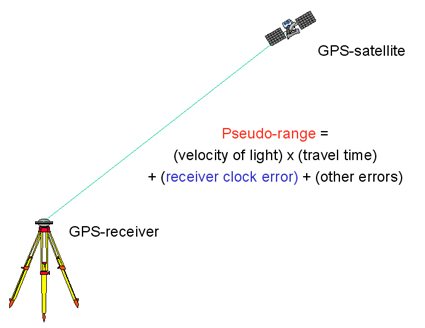

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)

# ---------------------------------------------------------
# LOAD INPUT DATA
# ---------------------------------------------------------

df_pseudorange = pd.read_excel(r'/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/Assignment2_Data/part1_data/pseudoranges.xlsx')
df_sat_pos = pd.read_excel(r'/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/Assignment2_Data/part1_data/satellite_position.xlsx')

pseudo_df = df_pseudorange
satpos_df = df_sat_pos

# Load the las column of the Pseudoranges measurements data
pseudorange = pseudo_df.iloc[:, 1].apply(pd.to_numeric, errors='coerce').to_numpy()

# Load the las three columns of the Satellite positions data
sat_positions = satpos_df.apply(pd.to_numeric, errors='coerce').iloc[:, -3:].to_numpy()

# ---------------------------------------------------------
# ADD RANDOM NOISE TO PSEUDORANGE MEASUREMENTS
# ---------------------------------------------------------
np.random.seed(42)  # For reproducible results
rng = np.random.default_rng()
noise = np.random.uniform(0, 0.5, size=pseudorange.shape)
pseudorange_noisy = pseudorange + noise

print(pseudorange)
print (pseudorange_noisy)
print (sat_positions)

print (pseudorange_noisy.shape)
print (sat_positions.shape)



[22919740.9614295 20459894.0877988 22400338.4134134 22829140.9126004
 22342014.8171753 25646454.5362932 23814776.2454228 24311399.3171521
 21353640.1406793 24971609.6374347 20638981.0590005]
[22919741.14869956 20459894.56315595 22400338.77941037 22829141.21192965
 22342014.89518462 25646454.61429046 23814776.2744646  24311399.75024017
 21353640.44123681 24971609.99147099 20638981.06929275]
[[  5280791.73836563 -25501460.1192133    4649508.28809917]
 [ -2159656.05205653 -21116024.7920163   15597909.1971221 ]
 [ 10371852.1682927  -21713111.3497771   10558686.998121  ]
 [-16085760.7811889    4285071.21612309  20742042.1246963 ]
 [-14312988.0806279  -22045014.2659254    4671208.3988653 ]
 [ -2435718.18737303  16257205.12951     21099779.5379103 ]
 [ 15912467.1868696   -3462515.31492602  21053628.253335  ]
 [ 16271848.163885     -218766.32031082  21035332.7037679 ]
 [-19247035.5286677   -7259803.67892242  16472981.9071979 ]
 [-15931152.0364578   12077367.2515846   18058076.7648504 ]
 [ -768

In [ ]:
# define the number of measurements n and the number of unknown states m
# (2 mark)

# Number of measurements
n = pseudorange.shape[0]  # number of rows (satellites)

# Number of unknown states for estimation of the 3 dimentional position and receiver clock state #(x,y,z, clock state)
m = 4

print("Number of measurements (n):", n)
print("Number of unknown states (m):", m)


Number of measurements (n): 11
Number of unknown states (m): 4


In [ ]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [ ]:
# ---------------------------------------------------------
# DEINITION OF GEOMETRIC DISTANCE COMPUTATION FUNCTION
# ---------------------------------------------------------

def euclidean_norm(receiver_pos, satellite_pos): #Input arrays are the position of the receiver and the satellite
    """
    Computes geometric distance between receiver (3x1)
    and each satellite position (Nx3)
    """
    diff_dist = satellite_pos - receiver_pos
    distances = np.linalg.norm(diff_dist, axis=1)

    return distances

## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [ ]:
# Weight matrix P
var = 1.2
P = np.eye(n) * (1 / var)

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [ ]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0])

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [ ]:
# Initializing the corrections array (delta) as 10s
delta = np.ones(m) * 10.0

# Iteration counter initialized as zero
i = 0

# Empty arrays to store results
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat =[]

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [ ]:
# ---------------------------------------------------------
# DESIGN MATRIX DEFINITION FOR LSE
# ---------------------------------------------------------

def design_matrix(receiver_pos, satellite_pos, distances):

    n = satellite_pos.shape[0]  # number of satellites
    A = np.zeros((n, 4))

    for j in range(n):
        # Computation of the difference between teh receiver postion and the satellite positions
        dx = receiver_pos[0] - satellite_pos[j, 0]
        dy = receiver_pos[1] - satellite_pos[j, 1]
        dz = receiver_pos[2] - satellite_pos[j, 2]

        # Computation of the artial derivatives
        A[j, 0] = dx / distances[j]
        A[j, 1] = dy / distances[j]
        A[j, 2] = dz / distances[j]

        # Inputing Clock bias term
        A[j, 3] = -1.0

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [ ]:
# ---------------------------------------------------------
# ITERATIVE LEAST-SQUARES ESTIMATION
# ---------------------------------------------------------

x_hat = np.array([100.0, -50.0, 25.0, 1000.0], dtype=float)

while np.linalg.norm(delta[:3]) > 0.008:

    # Conputation of Geometric distances
    distances = euclidean_norm(x_hat[:3], sat_positions)

    # Computation of Misclosure array
    w = pseudorange_noisy - (distances - x_hat[3])

    # Computation of Design matrix
    A = design_matrix(x_hat[:3], sat_positions, distances)

    # Computing Normal matrix and Right Hand Side Vector for correction calculation

    N = A.T @ P @ A
    u = A.T @ P @ w

    #Computing the corrections (Delta)
    delta = np.linalg.solve(N, u)

    # Update state
    x_hat = x_hat + delta

    # vector error wrt truth
    err_vec = x_hat[:3] - GroundTruth

    # scalar error
    err_pos = np.linalg.norm(err_vec)

    #Updating the counter
    i += 1

    # Storing the misclosure, delta, position error and counter from each iteration into arrays,
    arr_w.append(w)
    arr_delta.append(delta)
    arr_err_pos.append(err_pos)
    arr_i.append(i)

#Key computations after convergence
geom_dist_final = euclidean_norm(x_hat[:3], sat_positions)        #Final Geometric distance (after convergence)
A_final = design_matrix(x_hat[:3], sat_positions, geom_dist_final)#Final Design Matrix (after convergence)
w_final = pseudorange_noisy - (geom_dist_final - x_hat[3])        #Final Misclosure (after convergence)
N_final = A_final.T @ P @ A_final                                 #Final Normal matrix (after convergence)

# Residual computation
v = w_final - (A_final @ delta)

# Compution of the A Posteriori Variance of Unit Weight
apv = (v.T @ P @ v) / (n - 4)
apv = apv.item()

# Computation of the Covariance matrix of estimated states
C_x_hat = apv * np.linalg.pinv(N_final)

### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [ ]:
# ---------------------------------------------------------
# OUTPUT RESULTS
# ---------------------------------------------------------
# Convergence check
print("\nConverged?  ||delta_xyz|| < 0.008  ->",
      np.linalg.norm(delta[:3]) < 0.008)

print("\n======================================================")
print("                    FINAL RESULTS")
print("======================================================\n")

# Final estimated state
print("Final state estimate (x, y, z, clock):")
print(x_hat)

# Last correction
print("\nFinal corrections [dx, dy, dz, dclock]:")
print(delta)

# Total iterations
print("\nTotal number of iterations:", i)


# ---------------------------------------------------------
# Residuals
# ---------------------------------------------------------
print("\nVector of Residuals:")
print(v)

# ---------------------------------------------------------
# A posteriori variance
# ---------------------------------------------------------
print("\nA posteriori Variance of Unit Weight:")
print(apv)

# ---------------------------------------------------------
# Covariance matrix of estimates
# ---------------------------------------------------------
print("\nCovariance matrix of estimated states:")
print(C_x_hat)

# ---------------------------------------------------------
# 3-D POSITION ERROR PER ITERATION
# ---------------------------------------------------------
pos_err_per_iter = np.array(arr_err_pos)  # already scalars

print("\n================ 3-D POSITION ERROR PER ITERATION ================\n")
for k, val in enumerate(pos_err_per_iter, start=1):
    print(f"Iteration {k}:  {val:.6f} m")

print("\nFinal 3-D Position Error (m):", pos_err_per_iter[-1])




Converged?  ||delta_xyz|| < 0.008  -> True

                    FINAL RESULTS

Final state estimate (x, y, z, clock):
[-1.63349246e+06 -3.65162953e+06  4.95248542e+06 -6.70247977e+00]

Final corrections [dx, dy, dz, dclock]:
[ 3.24330127e-06  6.43110010e-06 -1.77329652e-05  2.09957835e-05]

Total number of iterations: 5

Vector of Residuals:
[ 0.20486387  0.34241698 -0.98041351  0.06601607  0.04711447 -1.57077215
 -0.30918658  1.69960168  0.33525769  0.74096804 -0.57574553]

A posteriori Variance of Unit Weight:
0.901367713485271

Covariance matrix of estimated states:
[[ 0.3457467   0.07534978 -0.09147658  0.07903424]
 [ 0.07534978  0.46020454 -0.62851089  0.3983237 ]
 [-0.09147658 -0.62851089  2.21260707 -1.19415431]
 [ 0.07903424  0.3983237  -1.19415431  0.75634562]]

================ 3-D POSITION ERROR PER ITERATION ================

Iteration 1:  1165503.207870 m
Iteration 2:  32942.531315 m
Iteration 3:  32.415231 m
Iteration 4:  5.425819 m
Iteration 5:  5.425802 m

Final 3-D Po

### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [ ]:
# Comment on the A Posterior Variance of Unit Weight

# The posteriori variance of unit weight is approximately 0.901. Since the value is smaller than one (1),
# it indicates that the residuals from the final linearized solution are slightly smaller than
# expected based on the assumed measurement noise. This further indicates that the linearization process
# was adequate and that the observational noise model was slightly conservative.
# Overall, the solution gives a good fit (fits the data well), and does not overestimate measurement errors.

# Comment on the Covariance Matrix of estimated states
# The covariance matrix shows that parameter 3 has the highest variance (2.21260707).
# This means that parameter 3 is the least precisely estimated parameter. In addition,
# the results show that there is a strong correlation between parameters 3 and 4 are,
# and this means that the changes in one can lead to changes in the other, further reflecting low sensitivity
# for some parameter combinations. Overall, the estimates are reliable, but some parameters are slightly less precise.

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

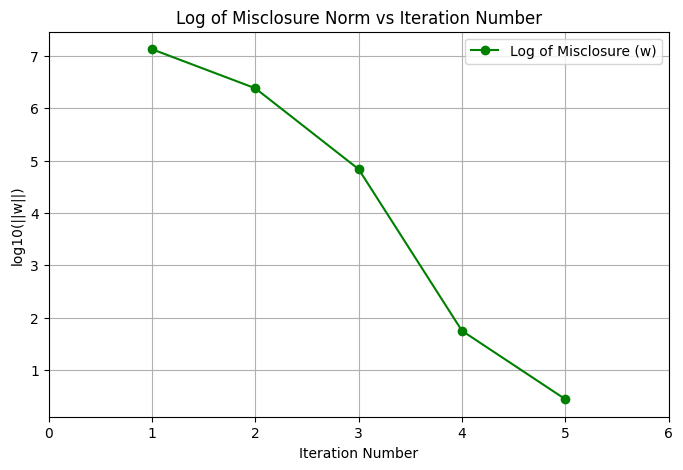

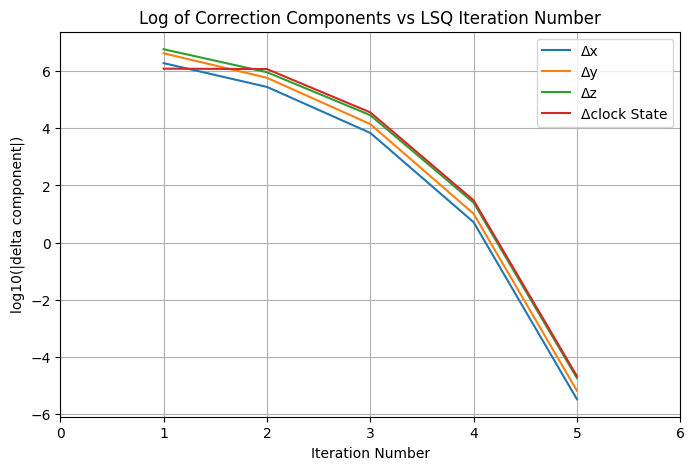

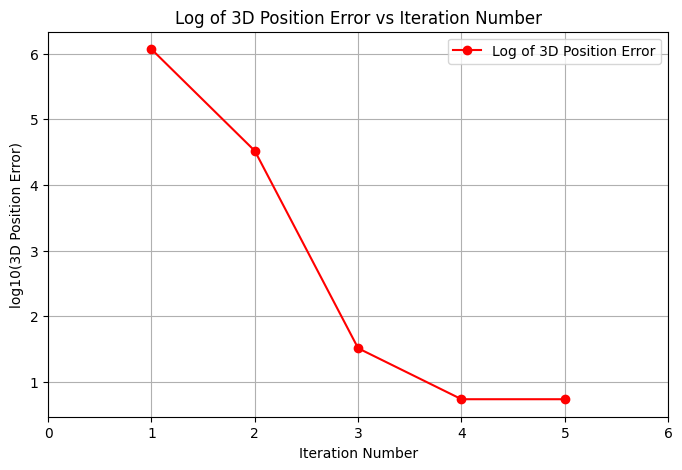

In [ ]:
# ---------------------------------------------------------
# PLOT PRODUCTION FOR LOG OF MISCLOSURE AGAINST ITERATION NUMBER
# ---------------------------------------------------------

# Computation of Misclosure Norm for each iteration
w_norm = [np.linalg.norm(w) for w in arr_w]

iterations = np.arange(1, len(w_norm) + 1) #Specifification iteration number

# Indication of plot properties
plt.figure(figsize=(8,5))
plt.plot(iterations, np.log10(w_norm), marker='o', color = 'g', label='Log of Misclosure (w)')
plt.xlabel("Iteration Number")
plt.ylabel("log10(||w||)")
plt.title("Log of Misclosure Norm vs Iteration Number")
plt.legend()
plt.grid(True)
plt.xlim(0, len(iterations)+1)   # ensures x
plt.show();

# -----------------------------------------------------------------------
# PLOT PRODUCTION FOR LOG OF CORRECTIONS (DELTA) AGAINST ITERATION NUMBER
# -----------------------------------------------------------------------

arr_delta = np.array(arr_delta)   # Convertion to array shape for plotting
iterations = np.arange(1, arr_delta.shape[0] + 1) #Specification of iteration number

# Indication of plot properties
plt.figure(figsize=(8,5))
plt.plot(iterations, np.log10(abs(arr_delta[:,0])), label="Δx")
plt.plot(iterations, np.log10(abs(arr_delta[:,1])), label="Δy")
plt.plot(iterations, np.log10(abs(arr_delta[:,2])), label="Δz")
plt.plot(iterations, np.log10(abs(arr_delta[:,3])), label="Δclock State")

plt.xlabel("Iteration Number")
plt.ylabel("log10(|delta component|)")
plt.title("Log of Correction Components vs LSQ Iteration Number")
plt.legend()
plt.grid(True)
plt.xlim(0, len(iterations)+1)   # ensures x-axis shows 0 to 5
plt.show();


# ---------------------------------------------------------
# LOG OF 3D POSTION ERRORS AGAINST ITERATION NUMBER
# ---------------------------------------------------------

pos_err = np.array(arr_err_pos)  # Provide list of 3D postion Errors and store in array
iterations = np.arange(1, len(pos_err) + 1) #Specification of Iteration numbers
eps = 1e-12  #including small epsilon to avoid log10(0)

# Indication of plot properties
plt.figure(figsize=(8,5))
plt.plot(iterations, np.log10(pos_err + eps), marker='o', color ='r', label='Log of 3D Position Error')
plt.xlabel("Iteration Number")
plt.ylabel("log10(3D Position Error)")
plt.title("Log of 3D Position Error vs Iteration Number")
plt.legend()
plt.grid(True)
plt.xlim(0, len(iterations) + 1)
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [ ]:
# Description of Plot of Log of Misclosure (w) against Iteration Number

# The plot of the log of the misclosure norm versus iteration number shows that the misclosure
# decreases rapidly at each step. Initially, the misclosure is very large,
# indicating a poor starting estimate. As the iterations proceed, the misclosures drop sharply
# and approach a small value by the final step, demonstrating that the nonlinear LSE converges efficiently
# and that the estimated parameters fit the observations well.

# Description of Plot of Log of corrections (delta) against Iteration Number
# The corrections show how much the parameters are updated at each iteration in the nonlinear LSE.
# Initially, the corrections are very large, indicating the starting estimate is far from the true solution.
# As the iterations progress, the corrections decrease rapidly. By the later iterations, the updates become extremely small,
# showing that the solution is stabilizing. This decreasing trend confirms that the nonlinear LSE converges efficiently and
# the estimated parameters no longer need significant changes.

# Description of Plot of Log of 3D Position Error against Iteration Number
# The plot of the log of the 3d position error against the iteration number shows how far the value of the
# estimated position is from the value of the true position of the receiver. At the initial stage, the error is very large,
# and this again indicates a poor starting estimate. As the iteration number increases, the error rapidly drops.
# At iteration number 4, a small error is already achieved and in the final iteration, the error stabilizes. This trend further
# shows quick convergence and that the estimated position becomes accurate and stable (stability achieved at iteration number 5)


### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [ ]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [ ]:
# -------------------------------------------------------
# COST FUNCTION DEFINITION
# -------------------------------------------------------
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
    rho = euclidean_norm(rec_pos, sat_pos)
    L = np.sum((pseudorange_noisy - (rho + cdT))**2)

    return L

rec_pos = np.array([100.0, -50.0, 25.0])
L = cost_function(rec_pos, cdT = 1000, sat_pos = sat_positions, pseudorange= pseudorange_noisy)


### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [ ]:
# -------------------------------------------------------
# GRADIENT COMPUTATION FUNCTION DEFINITION
# -------------------------------------------------------
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)

def gradient(rec_pos, cdT, sat_pos, pseudorange):
    rec_pos = np.array(rec_pos)
    sat_pos = np.array(sat_pos)

    # Vector of the difference between the satellite postion and the receiver position
    diff = rec_pos - sat_pos

    # Computation of the geometric ranges
    rho = np.sqrt(np.sum(diff**2, axis=1))
    rho = np.clip(rho, 1e-12, None)

    # Residuals: observed - model
    r = pseudorange_noisy - (rho + cdT)

    # Computation of Unit vectors from receiver to satellites
    ux = diff[:,0] / rho
    uy = diff[:,1] / rho
    uz = diff[:,2] / rho

    # Computed Gradients based on the derivatives (∂ρ/∂x)
    dL_dx   = -2 * np.sum(r * (ux))
    dL_dy   = -2 * np.sum(r * (uy))
    dL_dz   = -2 * np.sum(r * (uz))
    dL_dcdT = -2 * np.sum(r)

    grad = np.array([dL_dx, dL_dy, dL_dz, dL_dcdT])
    return grad


rec_pos = np.array([100.0, -50.0, 25.0])
grad = gradient(rec_pos, cdT = 1000, sat_pos = sat_positions, pseudorange= pseudorange_noisy)

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [ ]:
#-----------------------------------------#
# GRADIENT DESCENT IMPLEMENTATION FUNCTION
# ----------------------------------------#
# Construction of gradient descent impementation function using the provided default parameters
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):
    X = np.array([50.0, -25.0, 15.0, 500.0])

    arr_cost = []
    arr_grad = []
    arr_err = []

    steps = 0  # initialize step counter

    for iteration in range(max_iters):
        steps += 1  # increment every iteration

        rec_pos = X[:3]
        cdT = X[3]

        #Computation of current cost (cost_old)
        cost_old = cost_function(rec_pos, cdT, sat_pos, pseudorange)
        arr_cost.append(cost_old)

        #Computation of gradient at currect step
        g = gradient(rec_pos, cdT, sat_pos, pseudorange)
        arr_grad.append(np.linalg.norm(g))

        #Computation of updated estimates
        X_new = X - learning_rate * g

        #Computation of new cost (cost_new)
        cost_new = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)
        arr_err.append(abs(cost_new - cost_old))

        if abs(cost_new - cost_old) < tolerance:
            X = X_new
            print(f"\nConverged at iteration {steps}")
            break

        X = X_new

    return X, arr_cost, arr_grad, arr_err, steps


### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [ ]:
#------------------------------------------------------------------------------------------------#
# CALLING THE GRADIENT DESCENT IMPLEMENTATION FUNCTION USING DEFAULT OPTIMIZATION HYPERPARAMETERS
#               (USING THE LEARNING RATE AND MAXIMUM NUMBER OF ITEARTIONS)
# -----------------------------------------------------------------------------------------------#

#Calling of the gradient function using alternative learnin rate of 0.08 and maximum iteration number of 10000

optimized_params, arr_cost, arr_grad, arr_err, steps = gradient_descent(
    pseudorange_noisy, sat_positions, learning_rate=0.08, max_iters=10000, tolerance=8e-7)

# Extrcting final esitames
receiver_pos_final_XYZ = optimized_params[:3]
cdT_final = optimized_params[3]

#Computing Final Cost after convergence
final_cost = cost_function(receiver_pos_final_XYZ, cdT_final, sat_positions, pseudorange_noisy)

#Computing Final Gradient values after convergence
final_grad = gradient(receiver_pos_final_XYZ, cdT_final, sat_positions, pseudorange_noisy)

#GroundTruth Values (as provided)
GroundTruth = np.array([-1633489.37967725,-3651627.18250363, 4952481.61954918])

#Computation of Final Position Error
position_error = np.linalg.norm(receiver_pos_final_XYZ - GroundTruth)

# ==== OUTPUT PRINT ====
print("\n=====FINAL RESULTS (using default parameters (when Learning Rate = 0.08 and Maximum Number of iterations is 10000)=====)")

print("\n1. Optimized parameters:")
print("   Final receiver position (XYZ):", (receiver_pos_final_XYZ))
print("   Final cdT (meters):", cdT_final)

print("\n2. Final receiver position error (meters):")
print("   |estimated - GroundTruth| =", position_error)

print("\n3. Number of steps/Iterations taken for convergence:")
print("   step_count =", steps)

print("\n3. Final cost value:")
print("   cost value =", final_cost)

print("\n3. Final gradient values:")
print("     gradient values =", final_grad)


=====FINAL RESULTS (using default parameters (when Learning Rate = 0.08 and Maximum Number of iterations is 10000)=====)

1. Optimized parameters:
   Final receiver position (XYZ): [-1616184.59596918 -4389634.8224274   8306848.12640078]
   Final cdT (meters): 6327556.244673027

2. Final receiver position error (meters):
   |estimated - GroundTruth| = 3434636.719423592

3. Number of steps/Iterations taken for convergence:
   step_count = 10000

3. Final cost value:
   cost value = 255692970062035.5

3. Final gradient values:
     gradient values = [ 7.33346447e+06  2.01747337e+07 -3.40946836e+07  1.04702035e+08]


In [ ]:
#----------------------------------------------------------------------------------------#
# CALLING THE GRADIENT DESCENT IMPLEMENTATION FUNCTION USING ALTERNATIVE HYPERPARAMETERS
#       (IN THIS SECTION LEARNING RATE AND MAXIMUM NUMBER OF ITEARTIONS ARE CHANGED)
# ---------------------------------------------------------------------------------------#

#Calling of the gradient function using alternative learnin rate of 0.01 and maximum iteration number of 50000

optimized_params, arr_cost, arr_grad, arr_err, steps = gradient_descent(
    pseudorange_noisy, sat_positions, learning_rate=0.01, max_iters=50000, tolerance=8e-7)

# Extrcting final esitames
receiver_pos_final_XYZ = optimized_params[:3]
cdT_final = optimized_params[3]

#Computing Final Cost after convergence
final_cost = cost_function(receiver_pos_final_XYZ, cdT_final, sat_positions, pseudorange_noisy)

#Computing Final Gradient values after convergence
final_grad = gradient(receiver_pos_final_XYZ, cdT_final, sat_positions, pseudorange_noisy)

#GroundTruth Values (as provided)
GroundTruth = np.array([-1633489.37967725,-3651627.18250363, 4952481.61954918])

#Computation of Final Position Error
position_error = np.linalg.norm(receiver_pos_final_XYZ - GroundTruth)

# ==== OUTPUT PRINT ====
print("\n===========FINAL RESULTS  (when Learning Rate = 0.01 and Maximum Number of iterations is 50000)===========")

print("\n1. Optimized parameters:")
print("   Final receiver position (XYZ):", (receiver_pos_final_XYZ))
print("   Final cdT (meters):", cdT_final)

print("\n2. Final receiver position error (meters):")
print("   |estimated - GroundTruth| =", position_error)

print("\n3. Number of steps/Iterations taken for convergence:")
print("   step_count =", steps)

print("\n3. Final cost value:")
print("   cost value =", final_cost)

print("\n3. Final gradient values:")
print("     gradient values =", final_grad)


Converged at iteration 2888

===========FINAL RESULTS  (when Learning Rate = 0.01 and Maximum Number of iterations is 50000)===========

1. Optimized parameters:
   Final receiver position (XYZ): [-1633492.45540628 -3651629.52988384  4952485.41011031]
   Final cdT (meters): 6.696459272987952

2. Final receiver position error (meters):
   |estimated - GroundTruth| = 5.416517011530952

3. Number of steps/Iterations taken for convergence:
   step_count = 2888

3. Final cost value:
   cost value = 7.5715451102620355

3. Final gradient values:
     gradient values = [ 0.00043281  0.00241164 -0.00741199 -0.00420199]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

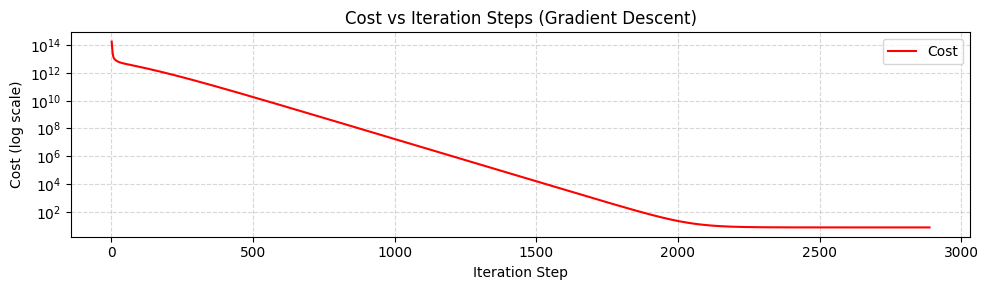

In [ ]:
# -------------------------------------------------------------------------------------------------#
# PLOT COST vs ITERATION STEPS (BASED ON LEARNING RATE = 0.01 AND MAXIMUM ITERATION NUMBER = 50000)
# -------------------------------------------------------------------------------------------------#

steps = np.arange(1, len(arr_cost)+1)
cost_values = np.array(arr_cost)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
ax.semilogy(steps, cost_values, color='r', label='Cost')

# Axes labels and title
ax.set_xlabel("Iteration Step")
ax.set_ylabel("Cost (log scale)")
ax.set_title("Cost vs Iteration Steps (Gradient Descent)")
ax.legend()

# Grid and layout
ax.grid(True, which='both', linestyle='--', alpha=0.5)
fig.tight_layout()

plt.show()

# -----Comment on the pattern of the plot-----#
# This plot shows the result for the optimization when the learning rate is 0.01 and the maximum iteration is 50,000
# The plot shows the cost function decreases rapidly in the initial stages, indicating effective movement toward a better
# solution. As iterations increases, there is a decline in the rate of decrease, and the curve begins to flatten.
# This suggests that the algorithm is approaching convergence. This behavior indicates a smooth optimization process.
# Overall, the pattern confirms that the algorithm is efficiently minimizing the cost and stabilizing near an optimal point


### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

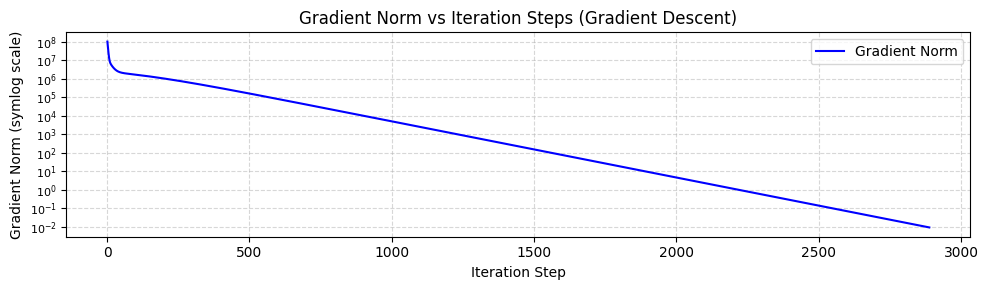

In [ ]:
# -----------------------------------------------------------------------------------------------------#
# PLOT GRADIENTS vs ITERATION STEPS (BASED ON LEARNING RATE = 0.01 AND MAXIMUM ITERATION NUMBER = 50000)
# -----------------------------------------------------------------------------------------------------#
grad_norm = np.array(arr_grad)
steps = np.arange(1, len(grad_norm)+1)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(steps, grad_norm, color='b', label='Gradient Norm')

# Addition of Symmetric log scale for y-axis (linear near zero, log elsewhere)
ax.set_yscale('symlog', linthresh=1e-6)

# Addition of Axis labels and title
ax.set_xlabel("Iteration Step")
ax.set_ylabel("Gradient Norm (symlog scale)")
ax.set_title("Gradient Norm vs Iteration Steps (Gradient Descent)")
ax.legend()

# Tick customization
ax.tick_params(axis='y', labelsize=8)

# Grid and layout
ax.grid(True, which='both', linestyle='--', alpha=0.5)
fig.tight_layout()

plt.show()

# -----Comment on the pattern of the plot-----#
# This plot shows the result for the optimization when the learning rate is 0.01 and the max. iteration is 50,000
# The plot of the gradient norm (which is plotted on a symmetric log scale) against the iteration steps,
# shows a clear and steady decrease over the course of iterations. At the initial stage, the gradient norm is
# extremely high, and it gradually reduces, converging at an iteration around 2880 step.
# This indicates an effective convergence of the optimization and the monotonic decline with no
# oscillations confirms that the gradient descent is efficiently minimizing the cost function

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

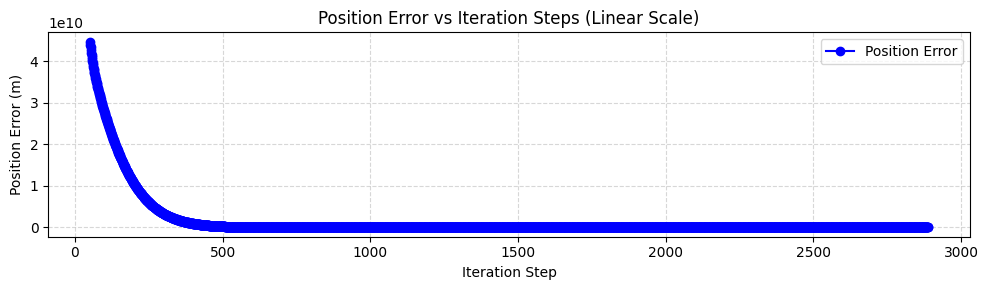

In [ ]:
# -----------------------------------------------------------------------------------------------------#
# PLOT GRADIENTS vs ITERATION STEPS (BASED ON LEARNING RATE = 0.01 AND MAXIMUM ITERATION NUMBER = 50000)
# -----------------------------------------------------------------------------------------------------#

#Skip first few iterations to focus on convergence
skip = 50
iterations = np.arange(1, len(arr_err) + 1)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(iterations[skip:], arr_err[skip:], marker='o', linestyle='-', color='b', label='Position Error')

# Addition of Axis labels and title
ax.set_xlabel('Iteration Step')
ax.set_ylabel('Position Error (m)')
ax.set_title('Position Error vs Iteration Steps (Linear Scale)')

# Addition of Grid and legend details
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
fig.tight_layout()
plt.show()

# -----Comment on the pattern of the plot-----#
# This plot shows how the position error changes over time during the iterative process.
# Initially, the error is extremely large, which suggests a poor starting estimate. However,
# the error drops sharply within the first few hundred iterations, indicating that the algorithm
# quickly adjusts toward a more accurate solution. As the iterations continue, the error
# steadily decreases and eventually flattens out, showing that the system has stabilized and converged.
# This pattern reflects a successful optimization process with strong corrective behavior early on and fine-tuning
# in later stages.


### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [ ]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

#----------------------------------------------------------------------------------------------------
# CALLING THE GRADIENT DESCENT IMPLEMENTATION FUNCTION USING ALTERNATIVE OPTIMIZATION HYPERPARAMETERS
#       (IN THIS SECTION LEARNING RATE AND MAXIMUM NUMBER OF ITEARTIONS ARE CHANGED)
# ---------------------------------------------------------------------------------------------------

#Calling of the gradient function using alternative learning rate of 0.008 and maximum iteration number of 50000

optimized_params_2, arr_cost, arr_grad, arr_err, steps = gradient_descent(
    pseudorange_noisy, sat_positions, learning_rate=0.008, max_iters=50000, tolerance=8e-7)

# Extrcting final esitames
receiver_pos_final_XYZ = optimized_params_2[:3]
cdT_final = optimized_params_2[3]

#Computing Final Cost after convergence
final_cost = cost_function(receiver_pos_final_XYZ, cdT_final, sat_positions, pseudorange_noisy)

#Computing Final Gradient values after convergence
final_grad = gradient(receiver_pos_final_XYZ, cdT_final, sat_positions, pseudorange_noisy)

#GroundTruth Values (as provided)
GroundTruth = np.array([-1633489.37967725,-3651627.18250363, 4952481.61954918])

#Computation of Final Position Error
position_error = np.linalg.norm(receiver_pos_final_XYZ - GroundTruth)

# ==== OUTPUT PRINT ====
print("\n===========FINAL RESULTS  (when Learning Rate = 0.008 and Maximum Number of iterations is 50000)===========")

print("\n1. Optimized parameters:")
print("   Final receiver position (XYZ):", (receiver_pos_final_XYZ))
print("   Final cdT (meters):", cdT_final)

print("\n2. Final receiver position error (meters):")
print("   |estimated - GroundTruth| =", position_error)

print("\n3. Number of steps/Iterations taken for convergence:")
print("   step_count =", steps)

print("\n3. Final cost value:")
print("   cost value =", final_cost)

print("\n3. Final gradient values:")
print("     gradient values =", final_grad)


Converged at iteration 3592

===========FINAL RESULTS  (when Learning Rate = 0.008 and Maximum Number of iterations is 50000)===========

1. Optimized parameters:
   Final receiver position (XYZ): [-1633492.45533083 -3651629.52946345  4952485.40881829]
   Final cdT (meters): 6.695726792590426

2. Final receiver position error (meters):
   |estimated - GroundTruth| = 5.4153878682329575

3. Number of steps/Iterations taken for convergence:
   step_count = 3592

3. Final cost value:
   cost value = 7.571559632584594

3. Final gradient values:
     gradient values = [ 0.00048548  0.00270503 -0.00831373 -0.0047133 ]


In [ ]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

#----------------------------------------------------------------------------------------------------
# CALLING THE GRADIENT DESCENT IMPLEMENTATION FUNCTION USING ALTERNATIVE OPTIMIZATION HYPERPARAMETERS
#       (IN THIS SECTION LEARNING RATE AND MAXIMUM NUMBER OF ITEARTIONS ARE CHANGED)
# ---------------------------------------------------------------------------------------------------

#Calling of the gradient function using alternative learnin rate of 0.0008 and maximum iteration number of 100000

optimized_params_2, arr_cost, arr_grad, arr_err, steps = gradient_descent(
    pseudorange_noisy, sat_positions, learning_rate=0.0008, max_iters=50000, tolerance=8e-7)

# Extrcting final esitames
receiver_pos_final_XYZ = optimized_params_2[:3]
cdT_final = optimized_params_2[3]

#Computing Final Cost after convergence
final_cost = cost_function(receiver_pos_final_XYZ, cdT_final, sat_positions, pseudorange_noisy)

#Computing Final Gradient values after convergence
final_grad = gradient(receiver_pos_final_XYZ, cdT_final, sat_positions, pseudorange_noisy)

#GroundTruth Values (as provided)
GroundTruth = np.array([-1633489.37967725,-3651627.18250363, 4952481.61954918])

#Computation of Final Position Error
position_error = np.linalg.norm(receiver_pos_final_XYZ - GroundTruth)

# ==== OUTPUT PRINT ====
print("\n===========FINAL RESULTS  (when Learning Rate = 0.0008 and Maximum Number of iterations is 50000)===========")

print("\n1. Optimized parameters:")
print("   Final receiver position (XYZ):", (receiver_pos_final_XYZ))
print("   Final cdT (meters):", cdT_final)

print("\n2. Final receiver position error (meters):")
print("   |estimated - GroundTruth| =", position_error)

print("\n3. Number of steps/Iterations taken for convergence:")
print("   step_count =", steps)

print("\n3. Final cost value:")
print("   cost value =", final_cost)

print("\n3. Final gradient values:")
print("     gradient values =", final_grad)


Converged at iteration 33929

===========FINAL RESULTS  (when Learning Rate = 0.0008 and Maximum Number of iterations is 50000)===========

1. Optimized parameters:
   Final receiver position (XYZ): [-1633492.4538036  -3651629.52095378  4952485.3826645 ]
   Final cdT (meters): 6.680899455094126

2. Final receiver position error (meters):
   |estimated - GroundTruth| = 5.392554018335137

3. Number of steps/Iterations taken for convergence:
   step_count = 33929

3. Final cost value:
   cost value = 7.5722122392327815

3. Final gradient values:
     gradient values = [ 0.00155142  0.00864443 -0.02656799 -0.01506209]


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [ ]:
# Answer to Question 1
# From the results obtained, changing the learning rate impacts the gradient descent solution. An increase in the
# learning rate leads to a faster convergence of the solution. The gradient descent takes larger steps towards the
# minimum and this reduces then number of iterations. However, when the learning rate is large, the updates because
# quite unstable and result in poor final estimates. On the other hands, when the learning rate is small, the solution
# converge more slowly but provide smoother, more stable, and more accurate final solutions, and they require more
# iterations to reach the minimum.

# Answer to Question 2
# The main difference between LSE and Gradient Descent lies in how they obtain the solution. LSE computes the estimate
# directly by solving the linearized least-squares equations, which is why it converged in only 5 iterations and produced
# a final position error of 5.4258 m. Gradient Descent, on the other hand, updates the parameters iteratively and depends
# heavily on the learning rate. From the optimization setting, Gradient Descent required 3592 iterations for a learning rate
# of 0.008 and 33929 iterations for a learning rate of 0.0008, even though it eventually reached a similar accuracy
# (approximately 5.40m final position error). This shows that LSE is computationally efficient and stable,
# while Gradient Descent is slower, sensitive to hyperparameter tuning, and may become unstable if the hyperparameters are not well tuned.
# However, Gradient Descent can still achieve comparable accuracy when the hyperparameters are effectively optimized.

---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [4]:
# Load the Student Depression Dataset
data = pd.read_csv(r'/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/Assignment2_Data/part2_data/Student Depression Dataset.csv')

# Basic data preprocessing
data.drop("id", axis=1, inplace=True)  # Remove irrelevant ID column
data.dropna(inplace=True)  # Remove rows with missing values
data.drop_duplicates(inplace=True)  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
cols = ["Job Satisfaction","Work Pressure"]
data = data.drop(columns=cols)

# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print(data.shape)
data.head()


(27898, 15)


,Gender,Age,City,Profession,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [5]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data["Depression"]                # Target vector
X = data.drop("Depression", axis=1)  # Feature matrix

# Display sizes of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (27898, 14)
y shape: (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

Class distribution (Count in each class):
Depression
1    16335
0    11563
Name: count, dtype: int64


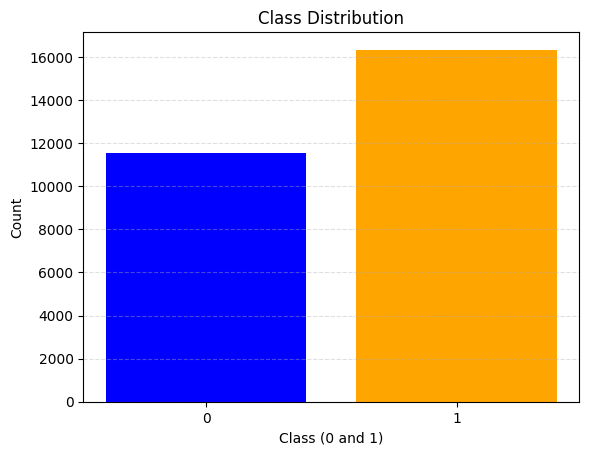

In [6]:
# Check the class distribution of y
# Display exact values for each bin in the histogram
# hint: Use for loop
# your code here


# Check the class distribution of y
print("Class distribution (Count in each class):")
print(y.value_counts())

class_counts = y.value_counts().sort_index()    # ensures order: 0 then 1

# Two colors for class 0 and class 1
colors = ['blue', 'orange']

# Bar plot
plt.bar(class_counts.index, class_counts.values, color=colors)

plt.title("Class Distribution")
plt.xlabel("Class (0 and 1)")
plt.ylabel("Count")
plt.xticks([0, 1])      # ensure only 0 and 1 appear

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [8]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
X_small, _, y_small, _ = train_test_split(
    X, y,
    test_size=0.97,      # keep ONLY 3% → remove 97%
    random_state=42
)

# Display sizes of X_small and y_small (0.5 marks)

print("X_small shape:", X_small.shape)
print("y_small shape:", y_small.shape)


X_small shape: (836, 14)
y_small shape: (836,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Complete steps 3, 4, and 5.1 in this code block

#step 3
# 1. Import LogisticRegression from sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

# 2. Instantiate the model
model = LogisticRegression(max_iter=2000)

# ====================================================
# ===============  DATASET 1: X and y  ===============
# ====================================================

# Train-test split
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.3, random_state=42 )

# Fit model
model.fit(X_train1, y_train1)

# Predictions
y_train_pred1 = model.predict(X_train1)
y_test_pred1 = model.predict(X_test1)

# Probabilities
y_train_proba1 = model.predict_proba(X_train1)
y_test_proba1 = model.predict_proba(X_test1)


# ==============================================================
# ==========  DATASET 2: First two columns of X  ===============
# ==============================================================

# Extract first two columns
X_two = X.iloc[:, :2]

# Train-test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_two, y, test_size=0.3, random_state=42)

# Train model
model.fit(X_train2, y_train2)

# Predictions
y_train_pred2 = model.predict(X_train2)
y_test_pred2 = model.predict(X_test2)

# Probabilities
y_train_proba2 = model.predict_proba(X_train2)
y_test_proba2 = model.predict_proba(X_test2)

# ====================================================
# ===============  DATASET 3: X_small  ===============
# ====================================================


# Train-test split
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_small, y_small, test_size=0.3, random_state=42)

# Train model
model.fit(X_train3, y_train3)

# Predictions
y_train_pred3 = model.predict(X_train3)
y_test_pred3 = model.predict(X_test3)

# Probabilities
y_train_proba3 = model.predict_proba(X_train3)
y_test_proba3 = model.predict_proba(X_test3)

### Step 4: Test Model (3 x 3 = 9 marks)
Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)


In [10]:
print("\n========== DATASET 1: X and y ==========")

# 1. Data size
data_size1 = X.shape[0]
print("1. Dataset 1 size:", data_size1)

# 2. Training samples
print("2. Dataset 1 (X,y) Training samples:", X_train1.shape[0])

# 3. Testing samples
print("3. Dataset 1 (X,y) Testing samples:", X_test1.shape[0])

# 4. Training accuracy
train_acc1 = accuracy_score(y_train1, y_train_pred1)
print("4. Dataset 1 (X,y) Training Accuracy:", train_acc1)

# 5. Testing accuracy
test_acc1 = accuracy_score(y_test1, y_test_pred1)
print("5. Dataset 1 (X,y) Testing Accuracy:", test_acc1)

# 6. Log loss
logloss1 = log_loss(y_test1, y_test_proba1)
print("6. Dataset 1 (X,y) Log Loss:", logloss1)

# ==========================================================
# ====================== DATASET 2 ==========================
# ============ First Two Columns of X =======================
# ==========================================================

print("\n========== DATASET 2: (First 2 Columns of X) ==========")

# 1. Data size
data_size2 = X_two.shape[0]
print("1. Dataset 2 (First 2 Columns of X, y) size:", data_size2)

# 2. Training samples
print("2. Dataset 2 (First 2 Columns of X, y) Training samples:", X_train2.shape[0])

# 3. Testing samples
print("3. Dataset 2 (First 2 Columns of X, y) Testing samples:", X_test2.shape[0])

# 4. Training accuracy
train_acc2 = accuracy_score(y_train2, y_train_pred2)
print("4. Dataset 2 (First 2 Columns of X, y) Training Accuracy:", train_acc2)

# 5. Testing accuracy
test_acc2 = accuracy_score(y_test2, y_test_pred2)
print("5. Dataset 2 (First 2 Columns of X, y) Testing Accuracy:", test_acc2)

# 6. Log loss
logloss2 = log_loss(y_test2, y_test_proba2)
print("6. Dataset 2 (First 2 Columns of X, y) Log Loss:", logloss2)



print("\n========== DATASET 3: X_small and y_small ==========")

# 1. Data size
data_size3 = X_small.shape[0]
print("1. Datatset 3 (X_small and y_small) size:", data_size3)

# 2. Training samples
print("2. Datatset 3 (X_small and y_small) Training samples:", X_train3.shape[0])

# 3. Testing samples
print("3. Datatset 3 (X_small and y_small) Testing samples:", X_test3.shape[0])

# Train model
model.fit(X_train3, y_train3)

# 4. Training accuracy
train_acc3 = accuracy_score(y_train3, y_train_pred3)
print("4. Datatset 3 (X_small and y_small) Training Accuracy:", train_acc3)

# 5. Testing accuracy
test_acc3 = accuracy_score(y_test3, y_test_pred3)
print("5. Datatset 3 (X_small and y_small) Testing Accuracy:", test_acc3)

# 6. Log loss
logloss3 = log_loss(y_test3, y_test_proba3)
print("6. Datatset 3 (X_small and y_small) Log Loss:", logloss3)


========== DATASET 1: X and y ==========
1. Dataset 1 size: 27898
2. Dataset 1 (X,y) Training samples: 19528
3. Dataset 1 (X,y) Testing samples: 8370
4. Dataset 1 (X,y) Training Accuracy: 0.8469889389594428
5. Dataset 1 (X,y) Testing Accuracy: 0.8463560334528076
6. Dataset 1 (X,y) Log Loss: 0.34979342899379756

========== DATASET 2: (First 2 Columns of X) ==========
1. Dataset 2 (First 2 Columns of X, y) size: 27898
2. Dataset 2 (First 2 Columns of X, y) Training samples: 19528
3. Dataset 2 (First 2 Columns of X, y) Testing samples: 8370
4. Dataset 2 (First 2 Columns of X, y) Training Accuracy: 0.6341151167554281
5. Dataset 2 (First 2 Columns of X, y) Testing Accuracy: 0.6285543608124253
6. Dataset 2 (First 2 Columns of X, y) Log Loss: 0.6531680189656458

========== DATASET 3: X_small and y_small ==========
1. Datatset 3 (X_small and y_small) size: 836
2. Datatset 3 (X_small and y_small) Training samples: 585
3. Datatset 3 (X_small and y_small) Testing samples: 251
4. Datatset 3 (X_sm

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000)

# DataFrame to store results
results = pd.DataFrame(columns=[
    "Data size", "Training samples", "Testing samples",
    "Training accuracy", "Testing accuracy", "Log loss"])

# ------------------------------
# Function to evaluate a dataset
# ------------------------------
def evaluate_model(X_data, y_data):

    # Ensure NumPy arrays (avoids feature-name errors)
    X_data = X_data.values if hasattr(X_data, "values") else X_data
    y_data = y_data.values if hasattr(y_data, "values") else y_data

    # 1. Data size
    data_size = X_data.shape[0]

    # Train-test split (70% train, 30% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.3, random_state=42
    )

    # 2. Training samples
    train_samples = X_train.shape[0]

    # 3. Testing samples
    test_samples = X_test.shape[0]

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities for log loss
    y_test_proba = model.predict_proba(X_test)

    # 4. Training accuracy
    train_acc = accuracy_score(y_train, y_train_pred)

    # 5. Testing accuracy
    test_acc = accuracy_score(y_test, y_test_pred)

    # 6. Log loss
    loss = log_loss(y_test, y_test_proba)

    return data_size, train_samples, test_samples, train_acc, test_acc, loss


# -----------------------------------------
# Test 1: Full dataset (X and y)
# -----------------------------------------
results.loc["Dataset 1 (X,y)"] = evaluate_model(X, y)

# -----------------------------------------
# Test 2: First two columns of X and y
# -----------------------------------------
X_two = X.iloc[:, :2]   # use iloc for pandas DataFrame
results.loc["Dataset 2 (First 2 Columns of X, y)"] = evaluate_model(X_two, y)

# -----------------------------------------
# Test 3: Small dataset (X_small and y_small)
# -----------------------------------------
results.loc["Dataset 3  (X_small and y_small"] = evaluate_model(X_small, y_small)

# Print final results table
print(results)




                                     Data size  Training samples  \
Dataset 1 (X,y)                        27898.0           19528.0   
Dataset 2 (First 2 Columns of X, y)    27898.0           19528.0   
Dataset 3  (X_small and y_small          836.0             585.0   

                                     Testing samples  Training accuracy  \
Dataset 1 (X,y)                               8370.0           0.846989   
Dataset 2 (First 2 Columns of X, y)           8370.0           0.634115   
Dataset 3  (X_small and y_small                251.0           0.868376   

                                     Testing accuracy  Log loss  
Dataset 1 (X,y)                              0.846356  0.349793  
Dataset 2 (First 2 Columns of X, y)          0.628554  0.653168  
Dataset 3  (X_small and y_small              0.820717  0.374555  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [ ]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set

y_test1 = y_test1                    # already created during split
y_test_pred1 = model.predict(X_test1)


Confusion Matrix:

[[2712  770]
 [ 516 4372]]


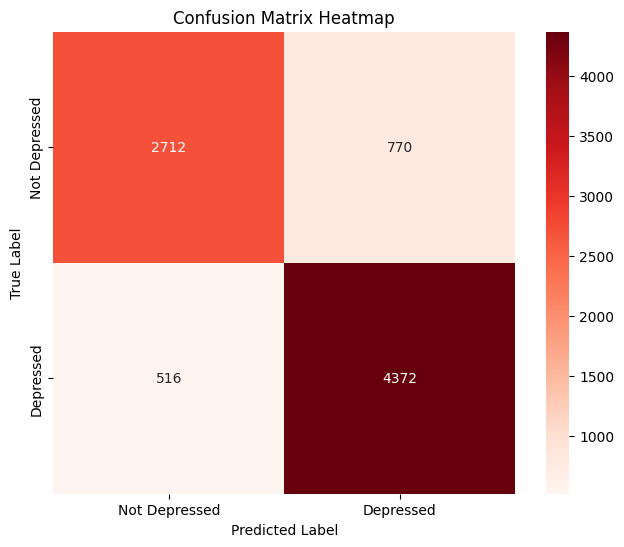

In [12]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)

cm = confusion_matrix(y_test1, y_test_pred1)
print("Confusion Matrix:\n")
print(cm)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            xticklabels=['Not Depressed', 'Depressed'],
            yticklabels=['Not Depressed', 'Depressed'],
            square=True,
            annot=True,
            cbar=True,
            fmt='d',
            cmap='Reds')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [13]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)

print("Classification Report:\n")
print(classification_report(y_test1, y_test_pred1,
                            target_names=['Not Depressed', 'Depressed']))


Classification Report:

               precision    recall  f1-score   support

Not Depressed       0.84      0.78      0.81      3482
    Depressed       0.85      0.89      0.87      4888

     accuracy                           0.85      8370
    macro avg       0.85      0.84      0.84      8370
 weighted avg       0.85      0.85      0.85      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models

# ----------------------------------------------------
# Initialize models
# ----------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

# ----------------------------------------------------
# Train and evaluate each model using the full dataset
# ----------------------------------------------------
model_results = {}

print("\n=== Model Comparison (Full Dataset) ===\n")

for name, model_instance in models.items():

    # Train the model
    model_instance.fit(X_train1, y_train1)

    # Make predictions
    y_pred = model_instance.predict(X_test1)

    # Calculate accuracy
    acc = accuracy_score(y_test1, y_pred)

    # Store results
    model_results[name] = acc

    # Print results
    print(f"{name}:")
    print(f"  Accuracy: {acc:.4f}\n")

# Final dictionary of results:
print("Summary of accuracies:", model_results)




=== Model Comparison (Full Dataset) ===

Logistic Regression:
  Accuracy: 0.8464

Naive Bayes:
  Accuracy: 0.8283

KNN (k=5):
  Accuracy: 0.7571

Summary of accuracies: {'Logistic Regression': 0.8463560334528076, 'Naive Bayes': 0.8283154121863799, 'KNN (k=5)': 0.7571087216248507}


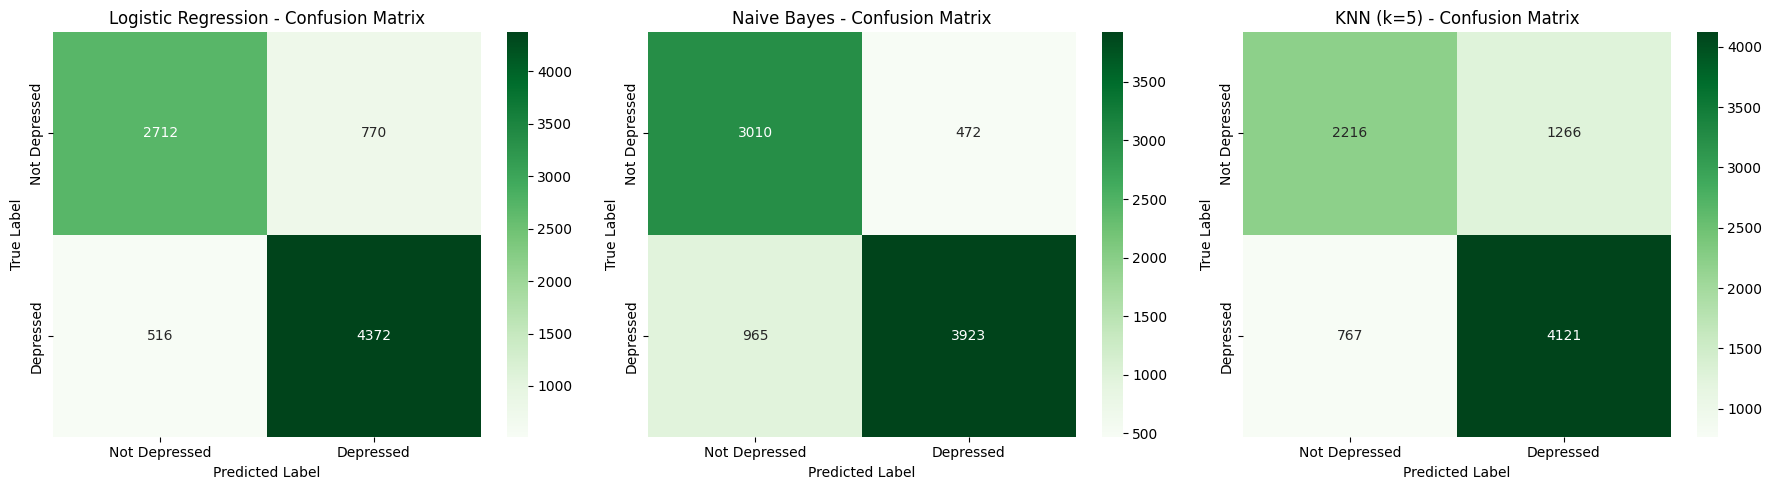

In [15]:
import seaborn as sns

# -----------------------------------------------
# Visualize confusion matrices for all models
# -----------------------------------------------

plt.figure(figsize=(18, 5))  # wide figure for 3 side-by-side heatmaps

for i, (name, model_instance) in enumerate(models.items(), 1):

    # Predict using testing set
    y_pred = model_instance.predict(X_test1)

    # Compute confusion matrix
    cm = confusion_matrix(y_test1, y_pred)

    # Plot heatmap
    plt.subplot(1, 3, i)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=["Not Depressed", "Depressed"],
        yticklabels=["Not Depressed", "Depressed"]
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

plt.tight_layout()
plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answer here (double click)


In [1]:
# Answer to Question 1
# From the data imbalance analysis, the dataset is moderately imbalanced, with 11,563 samples labeled as Not Depressed and
# 16,335 samples labeled as Depressed. This means that 59% of the samples are labeled depressed and 41% of the samples
# are labelled as Not depressed. While this imbalance is not severe, it could potentially cause models to slightly favour
# the majority class. However, it is important to note that in this case, the effect on the imbalance on model performance
# is minimal Both precision and recall scores for the two classes are high, and the overall accuracy is good.
# This suggests that, despite the moderate class imbalance, the model was able to generalize effectively across both classes.

# Answer to Question 2
# The training and testing accuracies in Dataset 1 are 0.8469) and (0.8462 respectively, which means that they are very close.
# This shows that the model is neither overfitting nor underfitting, and it generalizes well to unseen data.
# In Dataset 2, the values of the accuracies of the training and testing set are lower (both having approximately 0.63)
# because only two features are used in the mode, indicating that the model cannot learn enough from the input hence leading to underfitting.
# In Dataset 3, there is a slightly large gap between the training accuracy 0.8667 and the testing accuracy 0.8207.
# This suggests that the model slightly overfits, as the model captures patterns in the training data but does not
# generalize as effectively as expected to unseen data.

# Answer to Question 3
# In Dataset 1, the model benefits from full access to all features and close to 28,000 samples, resulting in consistently high training (0.8469)
# and testing (0.8462) accuracies. In contrast, restricting the dataset to only two features in Dataset 2 causes both training and testing accuracies
# to drop sharply to just above 0.63, indicating that the model lacks sufficient information to capture the underlying patterns.
# For Dataset 3, training accuracy remains high while testing accuracy slightly declines, highlighting that smaller datasets increase variability
# and the risk of overfitting. Overall, having a larger and more feature-rich dataset improves generalization and leads to higher accuracy.

# Answer to Question 4
# In this depression classification problem, a false positive occurs when the model incorrectly predicts that someone is depressed when they are not,
# while a false negative occurs when it predicts someone is not depressed when they actually are. False negatives are more concerning, as they fail to
# identify individuals who may need mental health support or intervention. Missing a true case of depression can delay necessary help, making false negatives
# the more serious error in this context.

# Answer to Question 5
# Since false negatives pose a greater risk, the priority should be to maximize recall for the “Depressed” class. High recall ensures that most truly
# depressed individuals are correctly identified. This can be achieved by applying approproate operations such as lowering the classification threshold,
# assigning class weights to penalize misclassification of depressed cases and oversampling the minority class using appropriate techniques. We can also
# optimizing the model using metrics such as recall, which place greater emphasis on minimizing false negatives. In addition to these options,
# adding features that are highly predictive of the positive class (depression) and removing irrelevant features that add noise can also help maximize the recall.

# Answer to Question 6
# Dataset 1 achieves the lowest log loss (approximately 0.3498), indicating the most reliable and well-calibrated predictions, thanks to access to all features.
# Dataset 2 has the highest log loss (approximately 0.6532) because the removal of most features severely limits predictive power, increasing uncertainty and
# leading to poorer probability estimates. Dataset 3, with a log loss of approximately 0.3745, performs better than Dataset 2 but worse than Dataset 1,
# indicating the instability that arises from using a very small dataset. The differences in log loss are mainly due to the the amount and richness
# of the data available to the model.

# Answer to Question 7
# Logistic Regression performs the best with an accuracy of 0.8462, as it handles large datasets well, captures linear relationships effectively, and
# produces well calibrated probability outputs. Naive Bayes follows with an accuracy of 0.8356. Even though its assumption that the features are independent
# is not entirely realistic, it still achieves reasonable performance. K-Nearest Neighbors (KNN) has the lowest performance, with an accuracy of 0.7572,
# because distance-based models like KNN are less effective in datasets with many features. In addition, KNN are sensitive to noise and generalize
# poorly unless the dataset is small and clean.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
# Load MNIST dataset from CSV files
train_csv_path = pd.read_csv('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/Assignment2_Data/part3-data/mnist_train.csv')
test_csv_path = pd.read_csv('/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/Assignment2_Data/part3-data/mnist_test.csv')

train_data = train_csv_path.values    # or your filename

y_train = train_data[:, 0]                  # labels
X_train = train_data[:, 1:]


# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28, 1)

# Load test data (0.5 marks)
test_data = test_csv_path.values
y_test = test_data[:, 0]
X_test = test_data[:, 1:]


# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1, 28, 28, 1)

# Display the shapes of training and test sets

print("The shape of X_train:", X_train.shape)
print("The shape of y_train:", y_train.shape)

print("The shape of X_test:", X_test.shape)
print("The shape of y_test:", y_test.shape)




The shape of X_train: (60000, 28, 28, 1)
The shape of y_train: (60000,)
The shape of X_test: (10000, 28, 28, 1)
The shape of y_test: (10000,)


Let's visualize some sample images to understand what our models will be learning from.

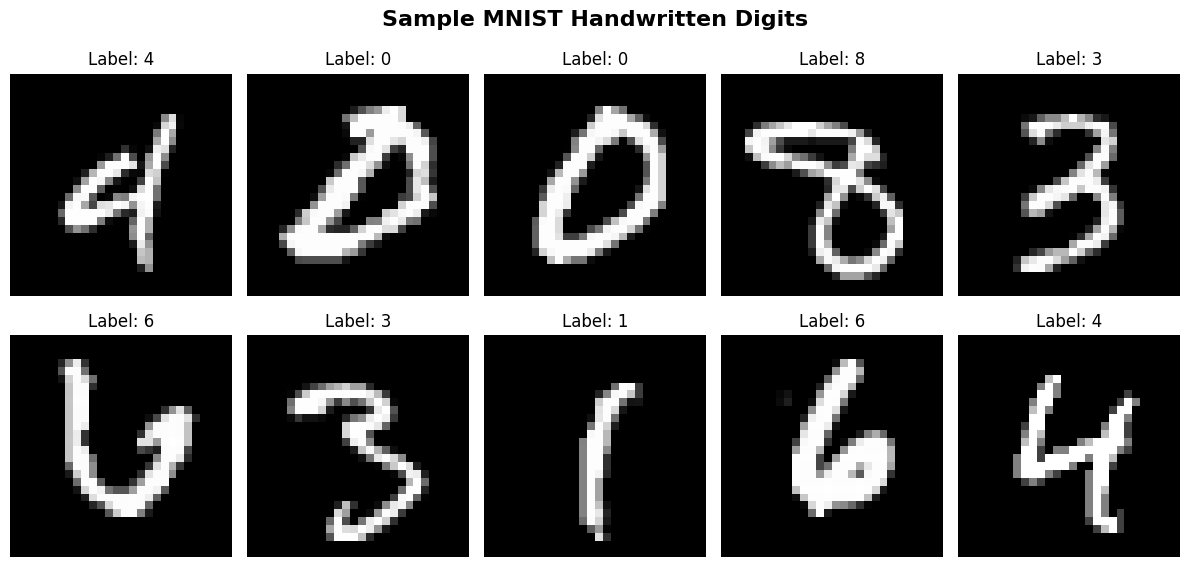

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train.astype("float32") / 255.0
X_test_normalized  = X_test.astype("float32") / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)

from keras.utils import to_categorical

num_classes = 10

y_train_categorical = to_categorical(y_train, num_classes)
y_test_categorical  = to_categorical(y_test, num_classes)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Flatten(),

        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),

        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),

        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation='relu'),

        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),

        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(10, activation='softmax')

    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")


MLP Model created


**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)
print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Create CNN model
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),

        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),

        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),

        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    # Same compile step with MLP (1 marks)
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")


CNN Model created


**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)
print("CNN training completed")

CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
# mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)
# your code here for cnn (1.5 marks)
# Similarly, convert CNN predicted probabilities to class labels
# Display Results


# -----------------------------
# Evaluate MLP Model
# -----------------------------
# Evaluate on test set
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)

# Predict probabilities
mlp_predictions = mlp_model.predict(X_test_normalized, verbose=0)

# Convert probabilities to class labels
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)



# -----------------------------
# Evaluate CNN Model
# -----------------------------
# Evaluate on test set
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)

# Predict probabilities
cnn_predictions = cnn_model.predict(X_test_normalized, verbose=0)

# Convert probabilities to class labels
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)


# -----------------------------
# Display Results
# -----------------------------
print("MLP Test Accuracy:", mlp_test_accuracy)
print("MLP Test Loss:", mlp_test_loss)

print("CNN Test Accuracy:", cnn_test_accuracy)
print("CNN Test Loss:", cnn_test_loss)


MLP Test Accuracy: 0.9714000225067139
MLP Test Loss: 0.0911002904176712
CNN Test Accuracy: 0.9882000088691711
CNN Test Loss: 0.03306971862912178


Performance comparison visualization

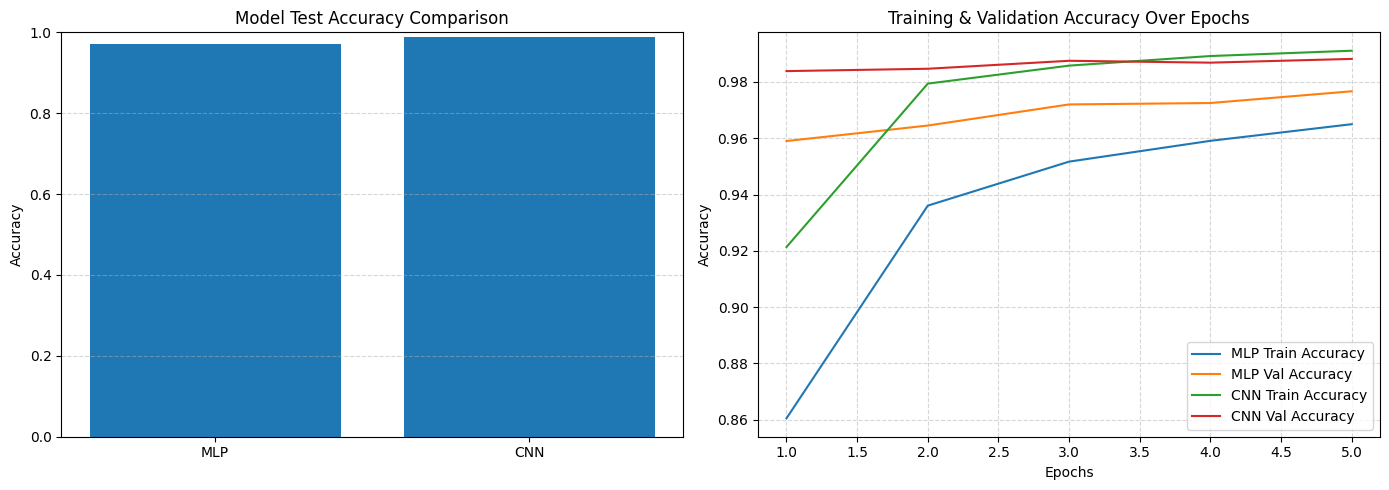

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step

# -----------------------------
# Extract training histories
# -----------------------------
mlp_train_acc = mlp_history.history['accuracy']
mlp_val_acc   = mlp_history.history['val_accuracy']

cnn_train_acc = cnn_history.history['accuracy']
cnn_val_acc   = cnn_history.history['val_accuracy']

epochs_range = range(1, len(mlp_train_acc) + 1)


# -----------------------------
# Create the figure with 2 plots side-by-side
# -----------------------------
plt.figure(figsize=(14, 5))

# ---------------------------------------------------
# 1. Bar Chart — MLP vs CNN Test Accuracy Comparison
# ---------------------------------------------------
plt.subplot(1, 2, 1)
models = ['MLP', 'CNN']
accuracies = [mlp_test_accuracy, cnn_test_accuracy]

plt.bar(models, accuracies)
plt.title("Model Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)


# ---------------------------------------------------
# 2. Line Plot — Training Progress
# ---------------------------------------------------
plt.subplot(1, 2, 2)

# MLP curves
plt.plot(epochs_range, mlp_train_acc, label="MLP Train Accuracy")
plt.plot(epochs_range, mlp_val_acc, label="MLP Val Accuracy")

# CNN curves
plt.plot(epochs_range, cnn_train_acc, label="CNN Train Accuracy")
plt.plot(epochs_range, cnn_val_acc, label="CNN Val Accuracy")

plt.title("Training & Validation Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

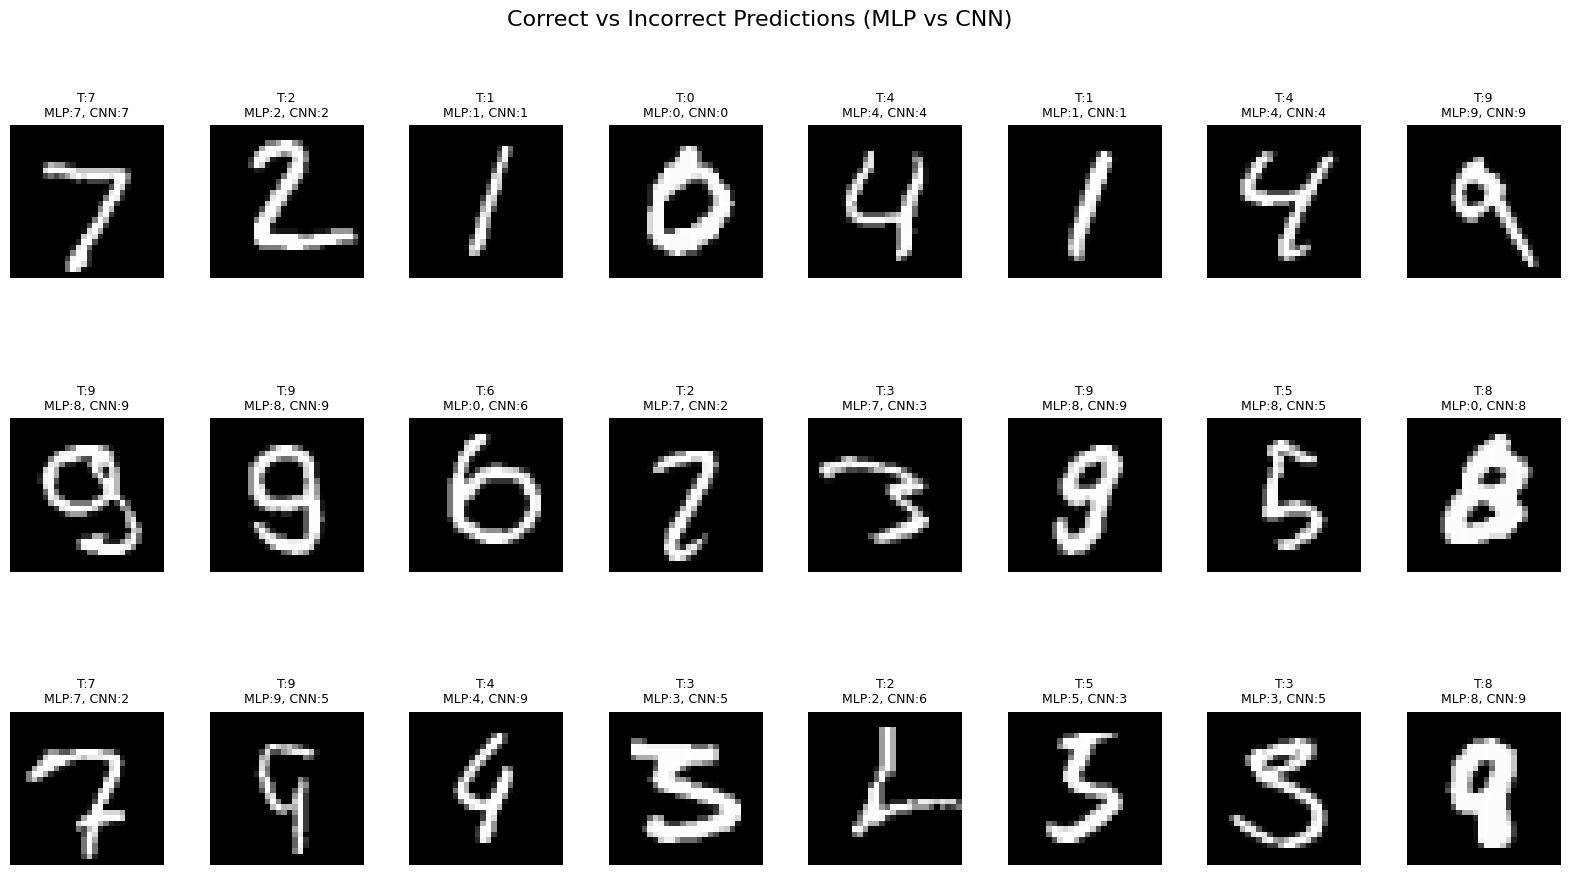

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)

# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)


# Find correct predictions for each case
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# ----------------------------------------------
# Create 3x8 subplot grid
# ----------------------------------------------
fig, axes = plt.subplots(3, 8, figsize=(20, 10))
fig.suptitle("Correct vs Incorrect Predictions (MLP vs CNN)", fontsize=16)

# Adjust spacing so titles show
fig.subplots_adjust(hspace=0.6, wspace=0.3)   # <<< FIX

# ----------------------------------------------
# Find sample indices for all 3 categories
# ----------------------------------------------

# 1. Both models correct
both_correct_indices = np.where(
    (mlp_predicted_classes == y_test) &
    (cnn_predicted_classes == y_test)
)[0][:8]

# 2. CNN correct, MLP wrong
cnn_correct_mlp_wrong_indices = np.where(
    (mlp_predicted_classes != y_test) &
    (cnn_predicted_classes == y_test)
)[0][:8]

# 3. MLP correct, CNN wrong
mlp_correct_cnn_wrong_indices = np.where(
    (mlp_predicted_classes == y_test) &
    (cnn_predicted_classes != y_test)
)[0][:8]


# ----------------------------------------------
# Helper function to plot a row of images
# ----------------------------------------------
def plot_row(indices, row):
    for col, idx in enumerate(indices):
        ax = axes[row, col]
        ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        ax.axis('off')

        true_label = y_test[idx]
        mlp_pred = mlp_predicted_classes[idx]
        cnn_pred = cnn_predicted_classes[idx]

        ax.set_title(f"T:{true_label}\nMLP:{mlp_pred}, CNN:{cnn_pred}", fontsize=9)


# ----------------------------------------------
# Plot each row
# ----------------------------------------------
plot_row(both_correct_indices, 0)
plot_row(cnn_correct_mlp_wrong_indices, 1)
plot_row(mlp_correct_cnn_wrong_indices, 2)

plt.show()


## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answer here (double click)


In [ ]:
# Answer to Question 1
# 1. The CNN model performed better the MLP because it achieved higher accuracy.
# Unlike the MLP, which treats each pixel independently, the CNN can learn spatial
# features such as edges and shapes. This ability to capture spatial
# structure allows the CNN to model image data more effectively, leading to better overall performance.

# Answer to Question 2
#2. When both training curves are compared, the MLP training curve indicates a slower improvement and
# a wider gap between the training and validation accuracy, and this could indicate mild overfitting.
# On the other hand, the CNN training curves improve more quickly. Reaches a higher accuracy and maintains
# smaller gap between the training and validation curves. This shows that CNN learns the spatial features of the
# image data more effectively and generalizes better than the MLP.

# Answer to Question 3
#3. The accuracy improvement percentage shows that CNN is better at correctly recognizing
# the digits compared to MLP. Although the accuracy improvement is 1.61%, it is still significant because
# it shows improved performance and again further indicates the capability of the CNN model to extract
# more useful spatial features from the dataset. In addition, the improvement shows that CNN is more
# reliable for real handwritten digit recognition.

# Answer to Question 4
#4. Many epochs were not needed because in this case the dataset used (MNIST) is quite
# simple and both models could quickly learn its pattern. Both networks could effectively extract useful
# features in only a small number of passes because the handwritten digits are clean and easy to separate.

# Answer to Question 5
#5. When the images are more complex, the performance gap between the CNN and MLP will be larger.
# MLPs would perform poorly and almost never perform better than CNN when the images are complex.
# This is mainly because MLP cannot capture spatial patterns and would require more parameters. On the other hands,
# CNN will still perform well but will require deeper layers, higher number of filters and a longer training
# time to deal with the image complexity.